**© Copyright AIDENTIFY. All rights reserved.**

본 자료는 **멀티캠퍼스 LLM 파인튜닝 과정** 수강생을 위해 제작되었으며, 강의 목적으로만 사용 가능합니다.  
무단 복제, 배포, 상업적 이용을 금지합니다.

---

# Session 12: 딥러닝 기본 원리 - 손실함수, 역전파, 하이퍼파라미터

**Part 3: 파인튜닝 기초** | GPU: Optional

---

### 📋 학습 목표
- 🎯 딥러닝의 핵심 구성 요소(뉴런, 활성화 함수, 손실 함수)를 이해한다
- 🎯 역전파와 경사하강법의 원리를 파악한다
- 🎯 주요 하이퍼파라미터의 역할과 튜닝 방법을 학습한다
- 🎯 PyTorch로 간단한 학습 루프를 직접 구현한다

### ⏱️ 예상 소요 시간: 90분

In [1]:
# 환경 설정 및 필수 라이브러리 import
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import gc

# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# GPU 메모리 모니터링 함수
def print_gpu_memory(tag=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"[{tag}] GPU: {allocated:.1f}GB / {total:.1f}GB")

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ PyTorch 버전: {torch.__version__}")
print(f"✅ 사용 디바이스: {device}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print_gpu_memory("초기 상태")
else:
    print("ℹ️ CPU 모드로 실행합니다 (이 노트북은 CPU로도 충분합니다)")

✅ PyTorch 버전: 2.10.0+cu128
✅ 사용 디바이스: cuda
✅ GPU: NVIDIA GeForce RTX 2070
[초기 상태] GPU: 0.0GB / 7.8GB


---
## 🎯 1. 딥러닝 기본 원리 개요

딥러닝은 **다층 신경망(Deep Neural Network)**을 사용하여 데이터에서 패턴을 학습하는 머신러닝의 한 분야입니다.

### 딥러닝 학습의 핵심 사이클

```
입력 데이터 → [순전파(Forward)] → 예측값 → [손실 계산] → 손실값
                                                           ↓
파라미터 업데이트 ← [옵티마이저] ← 그래디언트 ← [역전파(Backward)]
```

### 🔑 핵심 구성 요소

| 구성 요소 | 역할 | 예시 |
|-----------|------|------|
| **뉴런(Neuron)** | 입력을 받아 가중합 + 활성화 함수 적용 | `y = activation(Wx + b)` |
| **활성화 함수** | 비선형성 추가 | ReLU, Sigmoid, GELU |
| **손실 함수** | 예측과 정답의 차이 측정 | Cross-Entropy, MSE |
| **옵티마이저** | 파라미터 업데이트 방법 결정 | SGD, Adam, AdamW |
| **하이퍼파라미터** | 학습 과정 제어 | learning_rate, batch_size |

---
## 1️⃣ 2. 뉴런과 활성화 함수

### 뉴런(Neuron)의 구조

뉴런은 신경망의 기본 단위입니다:
- 📌 **입력(x)**: 이전 레이어에서 전달받는 값
- 📌 **가중치(W)**: 각 입력의 중요도
- 📌 **편향(b)**: 출력을 조절하는 상수
- 📌 **활성화 함수(σ)**: 비선형 변환

$$y = \sigma(Wx + b)$$

### 주요 활성화 함수

| 함수 | 수식 | 특징 |
|------|------|------|
| **Sigmoid** | $\frac{1}{1+e^{-x}}$ | 0~1 출력, Vanishing Gradient 문제 |
| **ReLU** | $\max(0, x)$ | 계산 효율적, Dead Neuron 문제 |
| **GELU** | $x \cdot \Phi(x)$ | 트랜스포머에서 주로 사용 |

📊 활성화 함수 비교 시각화


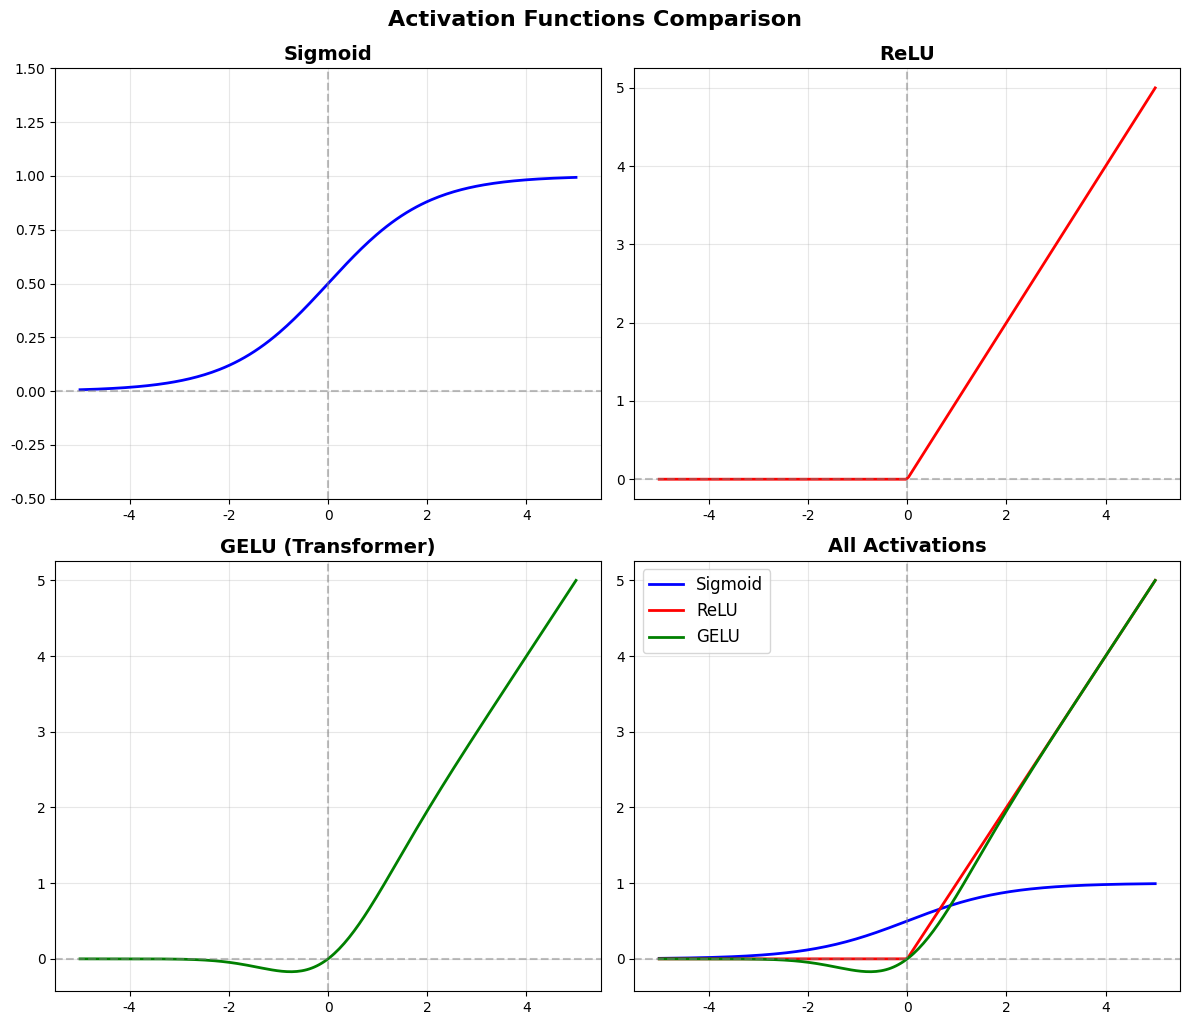


✅ 활성화 함수 시각화 완료!
💡 GELU는 GPT, BERT 등 트랜스포머 모델에서 표준 활성화 함수로 사용됩니다


In [2]:
# 활성화 함수 시각화
print("📊 활성화 함수 비교 시각화")
print("=" * 50)

x = torch.linspace(-5, 5, 200)

# 활성화 함수 계산
sigmoid = torch.sigmoid(x)
relu = torch.relu(x)
gelu = nn.functional.gelu(x)
tanh = torch.tanh(x)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Sigmoid
axes[0, 0].plot(x.numpy(), sigmoid.numpy(), 'b-', linewidth=2)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Sigmoid', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim(-0.5, 1.5)
axes[0, 0].grid(True, alpha=0.3)

# ReLU
axes[0, 1].plot(x.numpy(), relu.numpy(), 'r-', linewidth=2)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_title('ReLU', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# GELU
axes[1, 0].plot(x.numpy(), gelu.numpy(), 'g-', linewidth=2)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_title('GELU (Transformer)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 전체 비교
axes[1, 1].plot(x.numpy(), sigmoid.numpy(), 'b-', linewidth=2, label='Sigmoid')
axes[1, 1].plot(x.numpy(), relu.numpy(), 'r-', linewidth=2, label='ReLU')
axes[1, 1].plot(x.numpy(), gelu.numpy(), 'g-', linewidth=2, label='GELU')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_title('All Activations', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Activation Functions Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n✅ 활성화 함수 시각화 완료!")
print("💡 GELU는 GPT, BERT 등 트랜스포머 모델에서 표준 활성화 함수로 사용됩니다")

In [3]:
# 간단한 뉴런 동작 확인
print("🧠 단일 뉴런 동작 시뮬레이션")
print("=" * 50)

# 입력
x_input = torch.tensor([1.0, 2.0, 3.0])
# 가중치와 편향
weights = torch.tensor([0.5, -0.3, 0.8])
bias = torch.tensor(0.1)

# 가중합 계산
z = torch.dot(x_input, weights) + bias
print(f"📌 입력 x: {x_input.tolist()}")
print(f"📌 가중치 W: {weights.tolist()}")
print(f"📌 편향 b: {bias.item()}")
print(f"📌 가중합 z = Wx + b = {z.item():.4f}")

# 각 활성화 함수 적용
print(f"\n📊 활성화 함수 적용 결과:")
print(f"  Sigmoid(z) = {torch.sigmoid(z).item():.4f}")
print(f"  ReLU(z)    = {torch.relu(z).item():.4f}")
print(f"  GELU(z)    = {nn.functional.gelu(z).item():.4f}")
print(f"  Tanh(z)    = {torch.tanh(z).item():.4f}")

🧠 단일 뉴런 동작 시뮬레이션
📌 입력 x: [1.0, 2.0, 3.0]
📌 가중치 W: [0.5, -0.30000001192092896, 0.800000011920929]
📌 편향 b: 0.10000000149011612
📌 가중합 z = Wx + b = 2.4000

📊 활성화 함수 적용 결과:
  Sigmoid(z) = 0.9168
  ReLU(z)    = 2.4000
  GELU(z)    = 2.3803
  Tanh(z)    = 0.9837


---
## 2️⃣ 3. 손실 함수 (Loss Function)

손실 함수는 **모델의 예측이 정답과 얼마나 다른지** 를 수치로 나타냅니다.

### LLM에서 가장 중요한 손실 함수: Cross-Entropy Loss

$$\mathcal{L} = -\sum_{i=1}^{V} y_i \log(\hat{y}_i)$$

- 📌 $V$: 어휘(vocabulary) 크기
- 📌 $y_i$: 정답 (one-hot 벡터)
- 📌 $\hat{y}_i$: 모델의 예측 확률

### 왜 Cross-Entropy인가?
- 🎯 LLM은 **다음 토큰 예측(Next Token Prediction)** 문제
- 🎯 어휘 V개 중 하나를 선택하는 **분류(Classification)** 문제
- 🎯 Cross-Entropy는 분류 문제의 표준 손실 함수

In [4]:
# Cross-Entropy Loss 시각화 및 이해
print("📊 Cross-Entropy Loss 이해하기")
print("=" * 50)

# 예시: 어휘 크기 5인 간단한 언어 모델
vocab = ["나는", "오늘", "밥을", "먹었다", "공부했다"]
print(f"어휘(Vocabulary): {vocab}")
print(f"정답 토큰: '먹었다' (인덱스 3)")
print()

# 좋은 예측 vs 나쁜 예측
good_logits = torch.tensor([[1.0, 0.5, 0.3, 5.0, 0.2]])  # '먹었다'에 높은 점수
bad_logits = torch.tensor([[5.0, 0.5, 0.3, 0.2, 0.2]])   # '나는'에 높은 점수
target = torch.tensor([3])  # 정답: '먹었다'

criterion = nn.CrossEntropyLoss()

good_loss = criterion(good_logits, target)
bad_loss = criterion(bad_logits, target)

# Softmax로 확률 변환
good_probs = torch.softmax(good_logits, dim=1)
bad_probs = torch.softmax(bad_logits, dim=1)

print("🟢 좋은 예측 (정답에 높은 확률):")
for i, (word, prob) in enumerate(zip(vocab, good_probs[0])):
    marker = " ← 정답" if i == 3 else ""
    bar = "█" * int(prob * 50)
    print(f"  {word}: {prob:.3f} {bar}{marker}")
print(f"  Loss: {good_loss.item():.4f}")

print(f"\n🔴 나쁜 예측 (정답에 낮은 확률):")
for i, (word, prob) in enumerate(zip(vocab, bad_probs[0])):
    marker = " ← 정답" if i == 3 else ""
    bar = "█" * int(prob * 50)
    print(f"  {word}: {prob:.3f} {bar}{marker}")
print(f"  Loss: {bad_loss.item():.4f}")

print(f"\n💡 핵심: 정답 확률이 높을수록 Loss가 낮아집니다!")
print(f"   좋은 예측 Loss: {good_loss.item():.4f}")
print(f"   나쁜 예측 Loss: {bad_loss.item():.4f}")

📊 Cross-Entropy Loss 이해하기
어휘(Vocabulary): ['나는', '오늘', '밥을', '먹었다', '공부했다']
정답 토큰: '먹었다' (인덱스 3)

🟢 좋은 예측 (정답에 높은 확률):
  나는: 0.017 
  오늘: 0.011 
  밥을: 0.009 
  먹었다: 0.955 ███████████████████████████████████████████████ ← 정답
  공부했다: 0.008 
  Loss: 0.0457

🔴 나쁜 예측 (정답에 낮은 확률):
  나는: 0.965 ████████████████████████████████████████████████
  오늘: 0.011 
  밥을: 0.009 
  먹었다: 0.008  ← 정답
  공부했다: 0.008 
  Loss: 4.8360

💡 핵심: 정답 확률이 높을수록 Loss가 낮아집니다!
   좋은 예측 Loss: 0.0457
   나쁜 예측 Loss: 4.8360


📊 정답 확률에 따른 Cross-Entropy Loss 변화


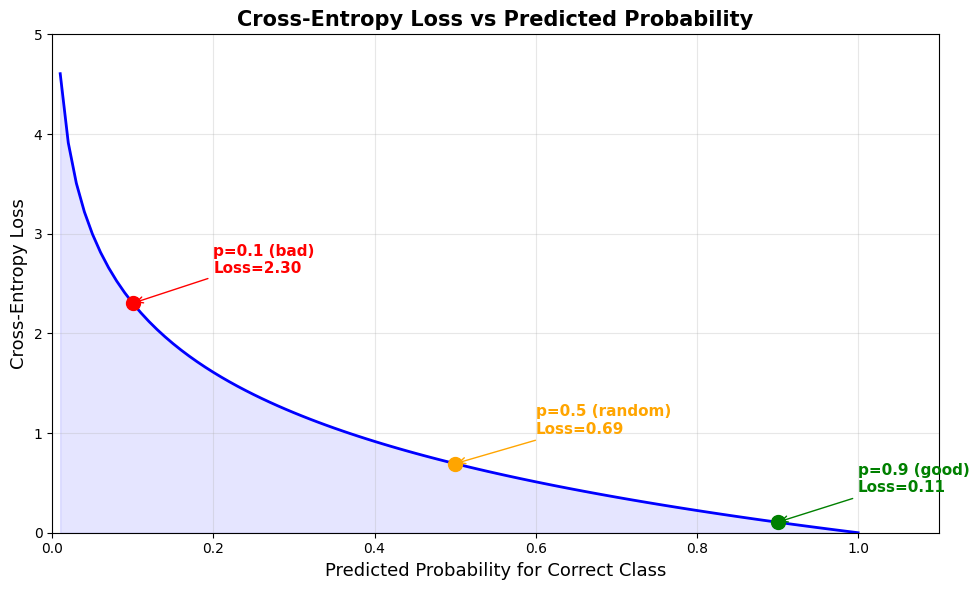


💡 핵심 인사이트:
  - 정답 확률이 0에 가까울수록 → Loss가 무한대로 발산
  - 정답 확률이 1에 가까울수록 → Loss가 0에 수렴
  - LLM 학습 시 Loss가 감소한다 = 정답 토큰의 예측 확률이 높아진다!


In [5]:
# Cross-Entropy Loss 곡선 시각화
print("📊 정답 확률에 따른 Cross-Entropy Loss 변화")
print("=" * 50)

probs = np.linspace(0.01, 1.0, 100)
losses = -np.log(probs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(probs, losses, 'b-', linewidth=2)
ax.fill_between(probs, losses, alpha=0.1, color='blue')

# 주요 포인트 표시
points = [(0.1, -np.log(0.1)), (0.5, -np.log(0.5)), (0.9, -np.log(0.9))]
labels = ['p=0.1 (bad)', 'p=0.5 (random)', 'p=0.9 (good)']
colors = ['red', 'orange', 'green']

for (px, py), label, color in zip(points, labels, colors):
    ax.scatter(px, py, s=100, c=color, zorder=5)
    ax.annotate(f'{label}\nLoss={py:.2f}', xy=(px, py), 
                xytext=(px + 0.1, py + 0.3), fontsize=11,
                arrowprops=dict(arrowstyle='->', color=color),
                color=color, fontweight='bold')

ax.set_xlabel('Predicted Probability for Correct Class', fontsize=13)
ax.set_ylabel('Cross-Entropy Loss', fontsize=13)
ax.set_title('Cross-Entropy Loss vs Predicted Probability', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

print("\n💡 핵심 인사이트:")
print("  - 정답 확률이 0에 가까울수록 → Loss가 무한대로 발산")
print("  - 정답 확률이 1에 가까울수록 → Loss가 0에 수렴")
print("  - LLM 학습 시 Loss가 감소한다 = 정답 토큰의 예측 확률이 높아진다!")

---
## 3️⃣ 4. 경사하강법과 역전파 (Backpropagation)

### 경사하강법 (Gradient Descent)

**목표**: 손실 함수를 최소화하는 파라미터(가중치)를 찾는 것

$$\theta_{new} = \theta_{old} - \eta \cdot \nabla_{\theta} \mathcal{L}$$

- 📌 $\theta$: 모델 파라미터 (가중치)
- 📌 $\eta$: 학습률 (Learning Rate)
- 📌 $\nabla_{\theta} \mathcal{L}$: 손실의 그래디언트

### 역전파 (Backpropagation)

- 📌 **순전파(Forward Pass)**: 입력 → 예측값 → 손실 계산
- 📌 **역전파(Backward Pass)**: 손실 → 각 파라미터의 그래디언트 계산
- 📌 **체인 룰(Chain Rule)**: 합성함수의 미분 법칙으로 그래디언트 전파

```
Forward:  x → [W1] → h1 → [W2] → h2 → [W3] → y → Loss
Backward: x ← [∂L/∂W1] ← h1 ← [∂L/∂W2] ← h2 ← [∂L/∂W3] ← y ← Loss
```

📊 경사하강법 시각화 - 손실 함수의 최솟값 찾기
초기 가중치: w = -1.00, Loss = 17.00
학습률: 0.1
목표: w = 3.0 (Loss = 1.0)

  Step  1: w = -0.2000, grad = -8.0000, Loss = 11.2400
  Step  2: w = 0.4400, grad = -6.4000, Loss = 7.5536
  Step  3: w = 0.9520, grad = -5.1200, Loss = 5.1943
  Step  4: w = 1.3616, grad = -4.0960, Loss = 3.6844
  Step  5: w = 1.6893, grad = -3.2768, Loss = 2.7180
  ... (중간 단계 생략) ...
  Step 14: w = 2.8241, grad = -0.4398, Loss = 1.0309
  Step 15: w = 2.8593, grad = -0.3518, Loss = 1.0198


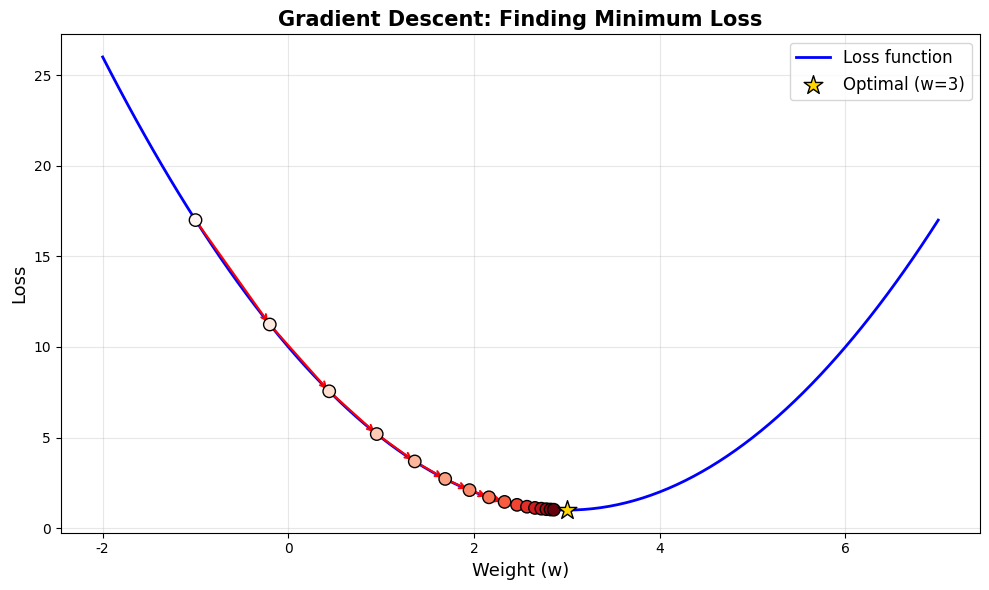


✅ 15번 업데이트 후 w = 2.8593 (목표: 3.0)
💡 핵심: 그래디언트 방향의 반대로 이동하면 Loss가 감소합니다!


In [6]:
# 경사하강법 시각화
print("📊 경사하강법 시각화 - 손실 함수의 최솟값 찾기")
print("=" * 50)

# 간단한 2차 함수: L(w) = (w - 3)^2 + 1
def loss_fn(w):
    return (w - 3)**2 + 1

def grad_fn(w):
    return 2 * (w - 3)

# 경사하강법 수행
w = -1.0  # 초기 가중치
lr = 0.1  # 학습률
history = [(w, loss_fn(w))]

print(f"초기 가중치: w = {w:.2f}, Loss = {loss_fn(w):.2f}")
print(f"학습률: {lr}")
print(f"목표: w = 3.0 (Loss = 1.0)")
print()

for step in range(15):
    grad = grad_fn(w)
    w = w - lr * grad
    loss = loss_fn(w)
    history.append((w, loss))
    if step < 5 or step >= 13:
        print(f"  Step {step+1:2d}: w = {w:.4f}, grad = {grad:.4f}, Loss = {loss:.4f}")
    elif step == 5:
        print(f"  ... (중간 단계 생략) ...")

# 시각화
w_range = np.linspace(-2, 7, 100)
loss_range = (w_range - 3)**2 + 1

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(w_range, loss_range, 'b-', linewidth=2, label='Loss function')

# 경사하강법 경로 표시
ws = [h[0] for h in history]
ls = [h[1] for h in history]
ax.scatter(ws, ls, c=range(len(ws)), cmap='Reds', s=80, zorder=5, edgecolors='black')
for i in range(len(ws)-1):
    ax.annotate('', xy=(ws[i+1], ls[i+1]), xytext=(ws[i], ls[i]),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# 최적점 표시
ax.scatter(3, 1, s=200, c='gold', marker='*', zorder=10, edgecolors='black', label='Optimal (w=3)')

ax.set_xlabel('Weight (w)', fontsize=13)
ax.set_ylabel('Loss', fontsize=13)
ax.set_title('Gradient Descent: Finding Minimum Loss', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ {len(history)-1}번 업데이트 후 w = {ws[-1]:.4f} (목표: 3.0)")
print("💡 핵심: 그래디언트 방향의 반대로 이동하면 Loss가 감소합니다!")

In [7]:
# PyTorch autograd 데모 - 자동 미분
print("🔧 PyTorch autograd (자동 미분) 데모")
print("=" * 50)

# requires_grad=True로 그래디언트 추적 활성화
w = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)

# 순전파
x = torch.tensor([3.0])
y_true = torch.tensor([7.0])

y_pred = w * x + b  # y = 2*3 + 1 = 7
loss = (y_pred - y_true) ** 2  # MSE

print(f"📌 순전파:")
print(f"   y_pred = w*x + b = {w.item():.1f} * {x.item():.1f} + {b.item():.1f} = {y_pred.item():.1f}")
print(f"   Loss = (y_pred - y_true)^2 = ({y_pred.item():.1f} - {y_true.item():.1f})^2 = {loss.item():.1f}")

# 역전파
loss.backward()

print(f"\n📌 역전파 (자동 미분):")
print(f"   dLoss/dw = {w.grad.item():.4f}")
print(f"   dLoss/db = {b.grad.item():.4f}")

# 수동 계산 검증
manual_dw = 2 * (y_pred.item() - y_true.item()) * x.item()
manual_db = 2 * (y_pred.item() - y_true.item())
print(f"\n📌 수동 계산 검증:")
print(f"   dLoss/dw = 2*(y_pred-y_true)*x = {manual_dw:.4f} ✅")
print(f"   dLoss/db = 2*(y_pred-y_true)   = {manual_db:.4f} ✅")
print(f"\n💡 PyTorch의 autograd가 자동으로 그래디언트를 계산해줍니다!")

🔧 PyTorch autograd (자동 미분) 데모
📌 순전파:
   y_pred = w*x + b = 2.0 * 3.0 + 1.0 = 7.0
   Loss = (y_pred - y_true)^2 = (7.0 - 7.0)^2 = 0.0

📌 역전파 (자동 미분):
   dLoss/dw = 0.0000
   dLoss/db = 0.0000

📌 수동 계산 검증:
   dLoss/dw = 2*(y_pred-y_true)*x = 0.0000 ✅
   dLoss/db = 2*(y_pred-y_true)   = 0.0000 ✅

💡 PyTorch의 autograd가 자동으로 그래디언트를 계산해줍니다!


---
## 4️⃣ 5. 옵티마이저 비교 (SGD, Adam, AdamW)

### 주요 옵티마이저

| 옵티마이저 | 특징 | 사용 사례 |
|-----------|------|----------|
| **SGD** | 기본 경사하강법 + 모멘텀 | 전통적 딥러닝 |
| **Adam** | 적응적 학습률 + 모멘텀 | 대부분의 딥러닝 |
| **AdamW** | Adam + Weight Decay 분리 | **LLM 학습 표준** |

### AdamW가 LLM의 표준인 이유
- 🎯 적응적 학습률: 파라미터마다 다른 학습률 적용
- 🎯 모멘텀: 이전 그래디언트의 이동 방향 반영 → 안정적 수렴
- 🎯 Weight Decay 정규화: L2 정규화를 올바르게 적용 (과적합 방지)

📊 옵티마이저 비교 실험


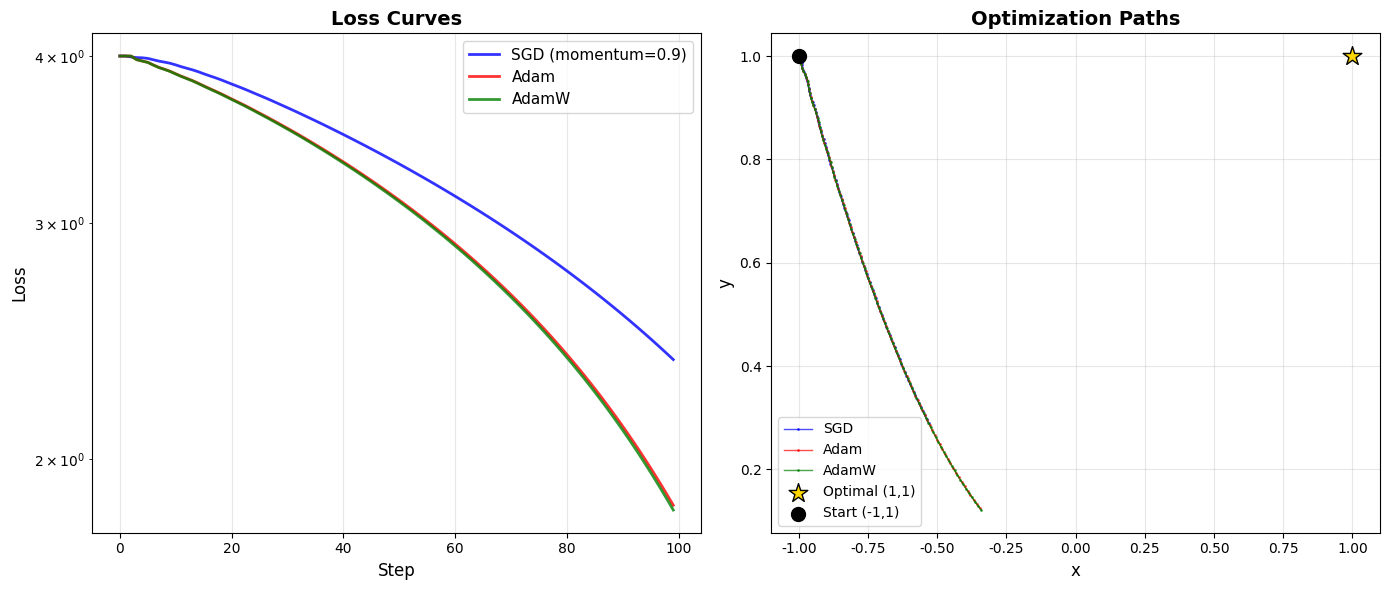


📊 최종 Loss 비교:
  SGD:   0.442065
  Adam:  0.219778
  AdamW: 0.219576

💡 LLM 파인튜닝에서는 AdamW가 표준 옵티마이저입니다!


In [8]:
# 옵티마이저 비교 실험
print("📊 옵티마이저 비교 실험")
print("=" * 50)

def rosenbrock(x, y):
    """Rosenbrock 함수 - 최적화 테스트에 자주 사용"""
    return (1 - x)**2 + 100*(y - x**2)**2

def run_optimizer(optimizer_class, lr, n_steps=200, **kwargs):
    """옵티마이저 실행 및 경로 기록"""
    x = torch.tensor([-1.0], requires_grad=True)
    y = torch.tensor([1.0], requires_grad=True)
    optimizer = optimizer_class([x, y], lr=lr, **kwargs)
    
    path = [(x.item(), y.item())]
    losses = [rosenbrock(x, y).item()]
    
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = rosenbrock(x, y)
        loss.backward()
        optimizer.step()
        path.append((x.item(), y.item()))
        losses.append(loss.item())
    
    return path, losses

# 각 옵티마이저 실행
sgd_path, sgd_losses = run_optimizer(optim.SGD, lr=0.0005, momentum=0.9)
adam_path, adam_losses = run_optimizer(optim.Adam, lr=0.01)
adamw_path, adamw_losses = run_optimizer(optim.AdamW, lr=0.01, weight_decay=0.01)

# Loss 곡선 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Loss 곡선
ax1.plot(sgd_losses[:100], 'b-', linewidth=2, label='SGD (momentum=0.9)', alpha=0.8)
ax1.plot(adam_losses[:100], 'r-', linewidth=2, label='Adam', alpha=0.8)
ax1.plot(adamw_losses[:100], 'g-', linewidth=2, label='AdamW', alpha=0.8)
ax1.set_xlabel('Step', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss Curves', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 최적화 경로
sgd_x, sgd_y = zip(*sgd_path[:100])
adam_x, adam_y = zip(*adam_path[:100])
adamw_x, adamw_y = zip(*adamw_path[:100])

ax2.plot(sgd_x, sgd_y, 'b.-', linewidth=1, markersize=2, label='SGD', alpha=0.7)
ax2.plot(adam_x, adam_y, 'r.-', linewidth=1, markersize=2, label='Adam', alpha=0.7)
ax2.plot(adamw_x, adamw_y, 'g.-', linewidth=1, markersize=2, label='AdamW', alpha=0.7)
ax2.scatter(1, 1, s=200, c='gold', marker='*', zorder=10, edgecolors='black', label='Optimal (1,1)')
ax2.scatter(-1, 1, s=100, c='black', marker='o', zorder=10, label='Start (-1,1)')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Optimization Paths', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 최종 Loss 비교:")
print(f"  SGD:   {sgd_losses[-1]:.6f}")
print(f"  Adam:  {adam_losses[-1]:.6f}")
print(f"  AdamW: {adamw_losses[-1]:.6f}")
print("\n💡 LLM 파인튜닝에서는 AdamW가 표준 옵티마이저입니다!")

---
## 5️⃣ 6. 핵심 하이퍼파라미터

LLM 파인튜닝에서 가장 중요한 하이퍼파라미터들입니다.

### 주요 하이퍼파라미터 정리

| 하이퍼파라미터 | 역할 | LLM 파인튜닝 권장값 |
|--------------|------|-------------------|
| **learning_rate** | 한 번에 얼마나 업데이트할지 | `1e-5` ~ `5e-5` (LoRA: `1e-4` ~ `3e-4`) |
| **batch_size** | 한 번에 처리할 데이터 수 | RTX 4060: `1~2` (VRAM 제한) |
| **gradient_accumulation_steps** | 가상 배치 사이즈 | `8~16` (effective batch = batch_size × steps) |
| **epochs** | 전체 데이터 반복 횟수 | `1~3` (과적합 주의) |
| **warmup_ratio** | 초반 학습률 증가 구간 | `0.03~0.1` |
| **max_seq_length** | 최대 시퀀스 길이 | RTX 4060: `1024~2048` |
| **weight_decay** | L2 정규화 강도 | `0.01~0.1` |

📊 Learning Rate에 따른 학습 차이


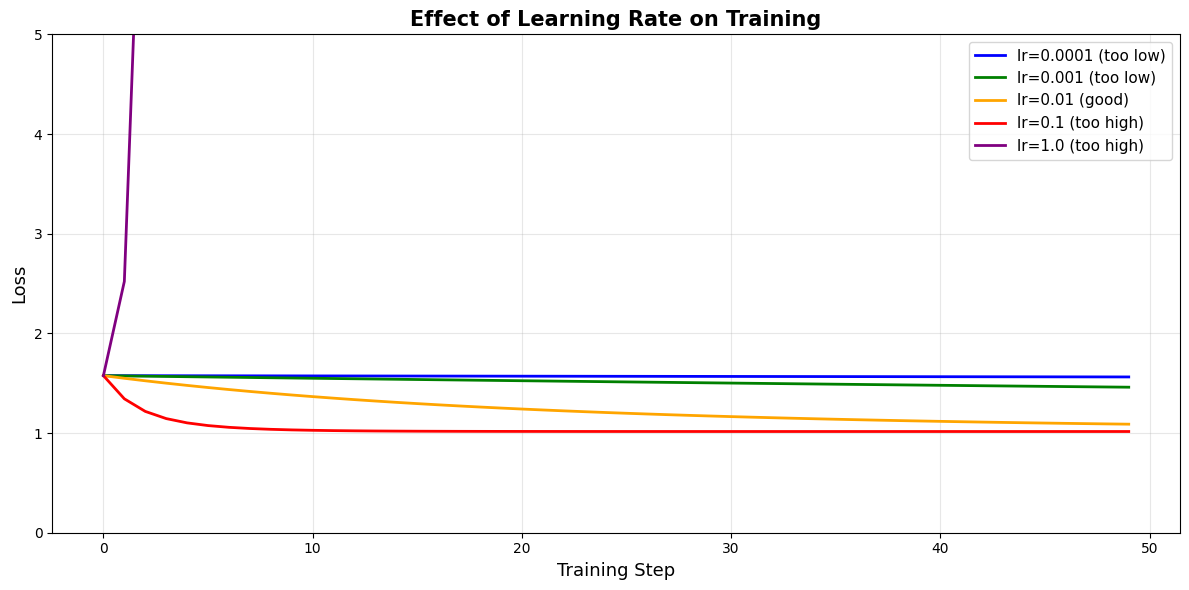


💡 핵심:
  - lr이 너무 작으면 → 학습이 매우 느림
  - lr이 너무 크면 → 학습이 불안정하거나 발산
  - 적절한 lr → 안정적이고 빠른 수렴


In [9]:
# Learning Rate의 영향 시각화
print("📊 Learning Rate에 따른 학습 차이")
print("=" * 50)

def simple_training(lr, n_steps=50):
    """간단한 학습 시뮬레이션"""
    torch.manual_seed(42)
    # 간단한 선형 모델
    model = nn.Linear(10, 1)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    # 더미 데이터
    x_data = torch.randn(100, 10)
    y_data = torch.randn(100, 1)
    
    losses = []
    for step in range(n_steps):
        pred = model(x_data)
        loss = nn.MSELoss()(pred, y_data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    return losses

# 다양한 학습률로 실험
lrs = [0.0001, 0.001, 0.01, 0.1, 1.0]
results = {}
for lr in lrs:
    results[lr] = simple_training(lr)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['blue', 'green', 'orange', 'red', 'purple']
for (lr, losses), color in zip(results.items(), colors):
    label = f'lr={lr}'
    if lr == 0.01:
        label += ' (good)'
    elif lr >= 0.1:
        label += ' (too high)'
    elif lr <= 0.001:
        label += ' (too low)'
    ax.plot(losses, color=color, linewidth=2, label=label)

ax.set_xlabel('Training Step', fontsize=13)
ax.set_ylabel('Loss', fontsize=13)
ax.set_title('Effect of Learning Rate on Training', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 핵심:")
print("  - lr이 너무 작으면 → 학습이 매우 느림")
print("  - lr이 너무 크면 → 학습이 불안정하거나 발산")
print("  - 적절한 lr → 안정적이고 빠른 수렴")

📊 Learning Rate Schedule: Warmup + Cosine Decay


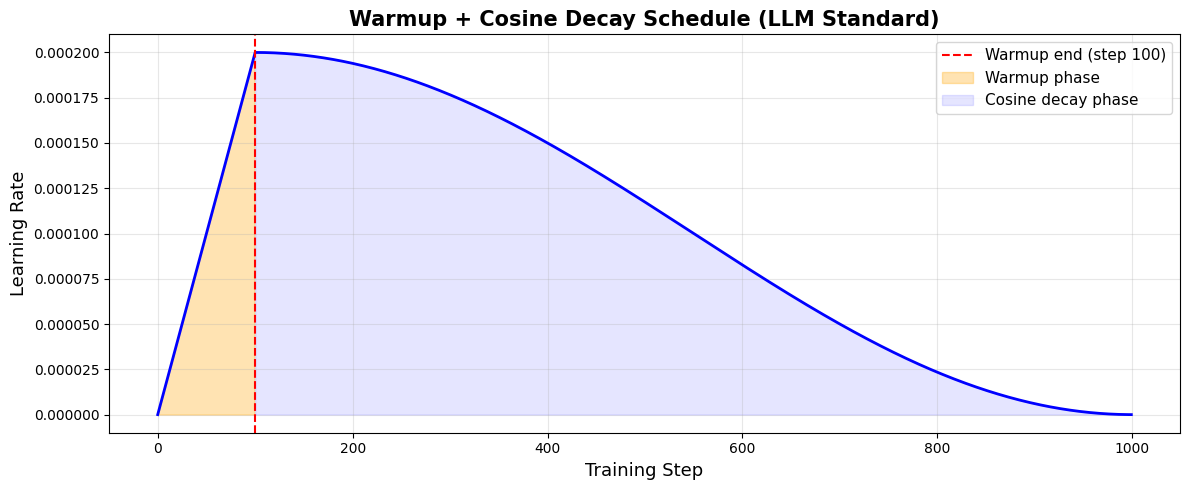


💡 Warmup이 필요한 이유:
  - 학습 초반에 그래디언트가 불안정
  - 작은 lr로 시작해서 점진적으로 올려야 안정적
  - warmup_ratio=0.03~0.1이 일반적


In [10]:
# Warmup + Cosine Decay 학습률 스케줄러 시각화
print("📊 Learning Rate Schedule: Warmup + Cosine Decay")
print("=" * 50)

total_steps = 1000
warmup_steps = 100
max_lr = 2e-4

# Warmup + Cosine Decay 계산
steps = np.arange(total_steps)
lr_schedule = []

for step in steps:
    if step < warmup_steps:
        # Linear warmup
        lr = max_lr * (step / warmup_steps)
    else:
        # Cosine decay
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        lr = max_lr * 0.5 * (1 + np.cos(np.pi * progress))
    lr_schedule.append(lr)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(steps, lr_schedule, 'b-', linewidth=2)
ax.axvline(x=warmup_steps, color='red', linestyle='--', label=f'Warmup end (step {warmup_steps})')
ax.fill_between(steps[:warmup_steps], lr_schedule[:warmup_steps], alpha=0.3, color='orange', label='Warmup phase')
ax.fill_between(steps[warmup_steps:], lr_schedule[warmup_steps:], alpha=0.1, color='blue', label='Cosine decay phase')

ax.set_xlabel('Training Step', fontsize=13)
ax.set_ylabel('Learning Rate', fontsize=13)
ax.set_title('Warmup + Cosine Decay Schedule (LLM Standard)', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Warmup이 필요한 이유:")
print("  - 학습 초반에 그래디언트가 불안정")
print("  - 작은 lr로 시작해서 점진적으로 올려야 안정적")
print("  - warmup_ratio=0.03~0.1이 일반적")

In [11]:
# Effective Batch Size 계산
print("📊 Effective Batch Size 이해하기")
print("=" * 50)

print("\n🎯 RTX 4060 (8GB VRAM) 환경에서의 배치 사이즈 전략:")
print()

scenarios = [
    {"batch_size": 1, "grad_accum": 1, "desc": "최소 설정"},
    {"batch_size": 1, "grad_accum": 8, "desc": "RTX 4060 권장 ✅"},
    {"batch_size": 1, "grad_accum": 16, "desc": "더 큰 effective batch"},
    {"batch_size": 2, "grad_accum": 8, "desc": "VRAM 여유 시"},
    {"batch_size": 4, "grad_accum": 4, "desc": "A100 등 대형 GPU"},
]

print(f"{'설정':20s} | {'batch_size':>12s} | {'grad_accum':>12s} | {'effective_batch':>16s}")
print("-" * 70)
for s in scenarios:
    effective = s['batch_size'] * s['grad_accum']
    print(f"{s['desc']:20s} | {s['batch_size']:>12d} | {s['grad_accum']:>12d} | {effective:>16d}")

print("\n💡 Gradient Accumulation을 사용하면:")
print("  - 작은 batch_size로도 큰 effective batch를 달성")
print("  - VRAM 사용량은 batch_size에만 비례")
print("  - 학습 안정성은 effective batch size에 비례")
print("  - ⚠️ 단, 학습 속도는 grad_accum 배만큼 느려짐")

📊 Effective Batch Size 이해하기

🎯 RTX 4060 (8GB VRAM) 환경에서의 배치 사이즈 전략:

설정                   |   batch_size |   grad_accum |  effective_batch
----------------------------------------------------------------------
최소 설정                |            1 |            1 |                1
RTX 4060 권장 ✅        |            1 |            8 |                8
더 큰 effective batch  |            1 |           16 |               16
VRAM 여유 시            |            2 |            8 |               16
A100 등 대형 GPU        |            4 |            4 |               16

💡 Gradient Accumulation을 사용하면:
  - 작은 batch_size로도 큰 effective batch를 달성
  - VRAM 사용량은 batch_size에만 비례
  - 학습 안정성은 effective batch size에 비례
  - ⚠️ 단, 학습 속도는 grad_accum 배만큼 느려짐


---
## 6️⃣ 7. 과적합과 정규화

### 과적합(Overfitting)이란?
- 📌 학습 데이터에는 잘 맞지만, 새로운 데이터에는 성능이 떨어지는 현상
- 📌 LLM 파인튜닝에서 특히 주의 필요 (데이터가 적을수록 심각)

### 주요 정규화 기법

| 기법 | 설명 | LLM 파인튜닝 적용 |
|------|------|------------------|
| **Dropout** | 학습 시 일부 뉴런을 무작위로 비활성화 | 모델 구조에 이미 포함 |
| **Weight Decay** | 가중치 크기에 비례하는 페널티 | AdamW의 `weight_decay=0.01` |
| **Early Stopping** | 검증 Loss가 증가하면 학습 중단 | epoch 수 제한 (1~3) |
| **데이터 증강** | 학습 데이터 다양화 | 합성 데이터 활용 |

📊 과적합 vs 적절한 학습 시뮬레이션


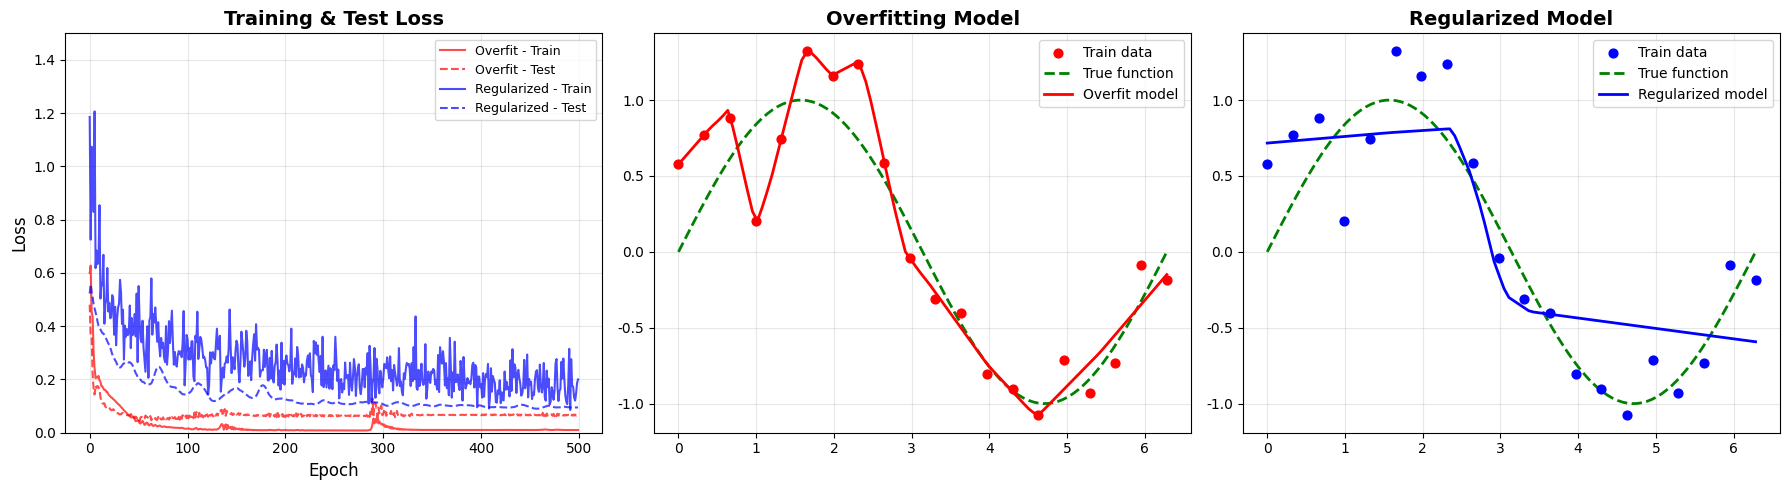


💡 관찰 포인트:
  - 과적합 모델: 학습 데이터는 완벽하게 맞추지만, 사이 구간에서 요동
  - 정규화 모델: 전체적인 패턴을 잘 학습 (일반화 성능 우수)
  - LLM 파인튜닝에서도 epoch을 1~3으로 제한하는 이유!


In [12]:
# 과적합 시뮬레이션
print("📊 과적합 vs 적절한 학습 시뮬레이션")
print("=" * 50)

torch.manual_seed(42)
np.random.seed(42)

# 학습 데이터 생성 (sin 함수 + 노이즈)
n_train = 20
x_train = torch.linspace(0, 2 * np.pi, n_train).unsqueeze(1)
y_train = torch.sin(x_train) + torch.randn_like(x_train) * 0.3

# 테스트 데이터
x_test = torch.linspace(0, 2 * np.pi, 100).unsqueeze(1)
y_test = torch.sin(x_test)

# 과적합 모델 (큰 모델, 정규화 없음)
class OverfitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 정규화 모델 (Dropout + 작은 모델)
class RegularizedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(16, 16), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

# 학습 함수
def train_model(model, optimizer, n_epochs=500):
    train_losses, test_losses = [], []
    criterion = nn.MSELoss()
    
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(x_train)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        model.eval()
        with torch.no_grad():
            test_pred = model(x_test)
            test_loss = criterion(test_pred, y_test)
            test_losses.append(test_loss.item())
    
    return train_losses, test_losses

# 학습 실행
torch.manual_seed(42)
overfit_model = OverfitModel()
overfit_opt = optim.Adam(overfit_model.parameters(), lr=0.01)
of_train, of_test = train_model(overfit_model, overfit_opt)

torch.manual_seed(42)
reg_model = RegularizedModel()
reg_opt = optim.AdamW(reg_model.parameters(), lr=0.01, weight_decay=0.01)
reg_train, reg_test = train_model(reg_model, reg_opt)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss 곡선 비교
axes[0].plot(of_train, 'r-', alpha=0.7, label='Overfit - Train')
axes[0].plot(of_test, 'r--', alpha=0.7, label='Overfit - Test')
axes[0].plot(reg_train, 'b-', alpha=0.7, label='Regularized - Train')
axes[0].plot(reg_test, 'b--', alpha=0.7, label='Regularized - Test')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Test Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.5)
axes[0].grid(True, alpha=0.3)

# 과적합 모델 예측
overfit_model.eval()
with torch.no_grad():
    of_pred = overfit_model(x_test)

axes[1].scatter(x_train.numpy(), y_train.numpy(), c='red', s=40, label='Train data', zorder=5)
axes[1].plot(x_test.numpy(), y_test.numpy(), 'g--', linewidth=2, label='True function')
axes[1].plot(x_test.numpy(), of_pred.numpy(), 'r-', linewidth=2, label='Overfit model')
axes[1].set_title('Overfitting Model', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 정규화 모델 예측
reg_model.eval()
with torch.no_grad():
    reg_pred = reg_model(x_test)

axes[2].scatter(x_train.numpy(), y_train.numpy(), c='blue', s=40, label='Train data', zorder=5)
axes[2].plot(x_test.numpy(), y_test.numpy(), 'g--', linewidth=2, label='True function')
axes[2].plot(x_test.numpy(), reg_pred.numpy(), 'b-', linewidth=2, label='Regularized model')
axes[2].set_title('Regularized Model', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 관찰 포인트:")
print("  - 과적합 모델: 학습 데이터는 완벽하게 맞추지만, 사이 구간에서 요동")
print("  - 정규화 모델: 전체적인 패턴을 잘 학습 (일반화 성능 우수)")
print("  - LLM 파인튜닝에서도 epoch을 1~3으로 제한하는 이유!")

---
## 🔬 8. 실습: 간단한 PyTorch 학습 루프 구현

지금까지 배운 개념을 종합하여 **간단한 분류 모델**을 처음부터 학습시켜봅시다.

### 실습 과제
- 📌 가상의 텍스트 분류 문제 (감성 분석 시뮬레이션)
- 📌 PyTorch 학습 루프: Forward → Loss → Backward → Update
- 📌 학습/검증 분리, Loss 시각화

In [13]:
# 데이터 준비 (감성 분석 시뮬레이션)
print("🔧 실습: PyTorch 학습 루프 구현")
print("=" * 50)
print("\n📌 과제: 간단한 분류 모델 학습 (감성 분석 시뮬레이션)")
print()

torch.manual_seed(42)

# 가상 데이터 생성 (100차원 특성, 2클래스)
n_samples = 500
n_features = 100

# 긍정/부정 샘플 생성
positive = torch.randn(n_samples // 2, n_features) + 0.5
negative = torch.randn(n_samples // 2, n_features) - 0.5

X = torch.cat([positive, negative], dim=0)
y = torch.cat([torch.ones(n_samples // 2), torch.zeros(n_samples // 2)]).long()

# 학습/검증 분리 (80:20)
indices = torch.randperm(n_samples)
train_idx = indices[:400]
val_idx = indices[400:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

print(f"✅ 데이터 생성 완료")
print(f"   학습 데이터: {X_train.shape[0]}개")
print(f"   검증 데이터: {X_val.shape[0]}개")
print(f"   특성 차원: {n_features}")
print(f"   클래스: 2 (긍정/부정)")

🔧 실습: PyTorch 학습 루프 구현

📌 과제: 간단한 분류 모델 학습 (감성 분석 시뮬레이션)

✅ 데이터 생성 완료
   학습 데이터: 400개
   검증 데이터: 100개
   특성 차원: 100
   클래스: 2 (긍정/부정)


In [14]:
# 모델 정의
print("🏗️ 모델 정의")
print("=" * 50)

class SimpleClassifier(nn.Module):
    """간단한 2층 분류 신경망"""
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.GELU()  # 트랜스포머에서 사용하는 활성화 함수
        self.dropout = nn.Dropout(0.1)
        self.layer2 = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        x = self.layer1(x)         # 선형 변환
        x = self.activation(x)     # 비선형 활성화
        x = self.dropout(x)        # 정규화
        x = self.layer2(x)         # 출력 레이어
        return x

# 모델 생성
model = SimpleClassifier(input_dim=100, hidden_dim=64, num_classes=2)
model = model.to(device)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ 모델 생성 완료")
print(f"   총 파라미터 수: {total_params:,}")
print(f"   학습 가능 파라미터: {trainable_params:,}")
print(f"\n📋 모델 구조:")
print(model)

if torch.cuda.is_available():
    print_gpu_memory("모델 로드 후")

🏗️ 모델 정의
✅ 모델 생성 완료
   총 파라미터 수: 6,594
   학습 가능 파라미터: 6,594

📋 모델 구조:
SimpleClassifier(
  (layer1): Linear(in_features=100, out_features=64, bias=True)
  (activation): GELU(approximate='none')
  (dropout): Dropout(p=0.1, inplace=False)
  (layer2): Linear(in_features=64, out_features=2, bias=True)
)
[모델 로드 후] GPU: 0.0GB / 7.8GB


In [15]:
# 학습 루프 구현
print("🚀 학습 시작!")
print("=" * 50)

# 하이퍼파라미터 설정
learning_rate = 1e-3
num_epochs = 50
batch_size = 32

print(f"📌 하이퍼파라미터:")
print(f"   learning_rate: {learning_rate}")
print(f"   num_epochs: {num_epochs}")
print(f"   batch_size: {batch_size}")
print(f"   optimizer: AdamW (weight_decay=0.01)")
print(f"   loss: CrossEntropyLoss")
print()

# 옵티마이저와 손실 함수
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# 데이터를 디바이스로 이동
X_train_dev = X_train.to(device)
y_train_dev = y_train.to(device)
X_val_dev = X_val.to(device)
y_val_dev = y_val.to(device)

# 학습 기록
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    # ===== 학습 단계 =====
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    # 미니배치 학습
    for i in range(0, len(X_train_dev), batch_size):
        batch_x = X_train_dev[i:i+batch_size]
        batch_y = y_train_dev[i:i+batch_size]
        
        # 1. Forward Pass
        outputs = model(batch_x)
        
        # 2. Loss 계산
        loss = criterion(outputs, batch_y)
        
        # 3. Backward Pass
        optimizer.zero_grad()
        loss.backward()
        
        # 4. Parameter Update
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    
    train_loss = epoch_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # ===== 검증 단계 =====
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_dev)
        val_loss = criterion(val_outputs, y_val_dev).item()
        _, val_predicted = torch.max(val_outputs, 1)
        val_acc = (val_predicted == y_val_dev).sum().item() / len(y_val_dev)
    
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # 로그 출력
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:3d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

print(f"\n✅ 학습 완료!")
print(f"   최종 학습 정확도: {train_accs[-1]:.1%}")
print(f"   최종 검증 정확도: {val_accs[-1]:.1%}")

🚀 학습 시작!
📌 하이퍼파라미터:
   learning_rate: 0.001
   num_epochs: 50
   batch_size: 32
   optimizer: AdamW (weight_decay=0.01)
   loss: CrossEntropyLoss

  Epoch [  1/50] Train Loss: 0.3943 | Train Acc: 0.920 | Val Loss: 0.1752 | Val Acc: 1.000
  Epoch [ 10/50] Train Loss: 0.0022 | Train Acc: 1.000 | Val Loss: 0.0022 | Val Acc: 1.000
  Epoch [ 20/50] Train Loss: 0.0007 | Train Acc: 1.000 | Val Loss: 0.0007 | Val Acc: 1.000
  Epoch [ 30/50] Train Loss: 0.0003 | Train Acc: 1.000 | Val Loss: 0.0004 | Val Acc: 1.000
  Epoch [ 40/50] Train Loss: 0.0002 | Train Acc: 1.000 | Val Loss: 0.0003 | Val Acc: 1.000
  Epoch [ 50/50] Train Loss: 0.0001 | Train Acc: 1.000 | Val Loss: 0.0002 | Val Acc: 1.000

✅ 학습 완료!
   최종 학습 정확도: 100.0%
   최종 검증 정확도: 100.0%


📊 학습 결과 시각화


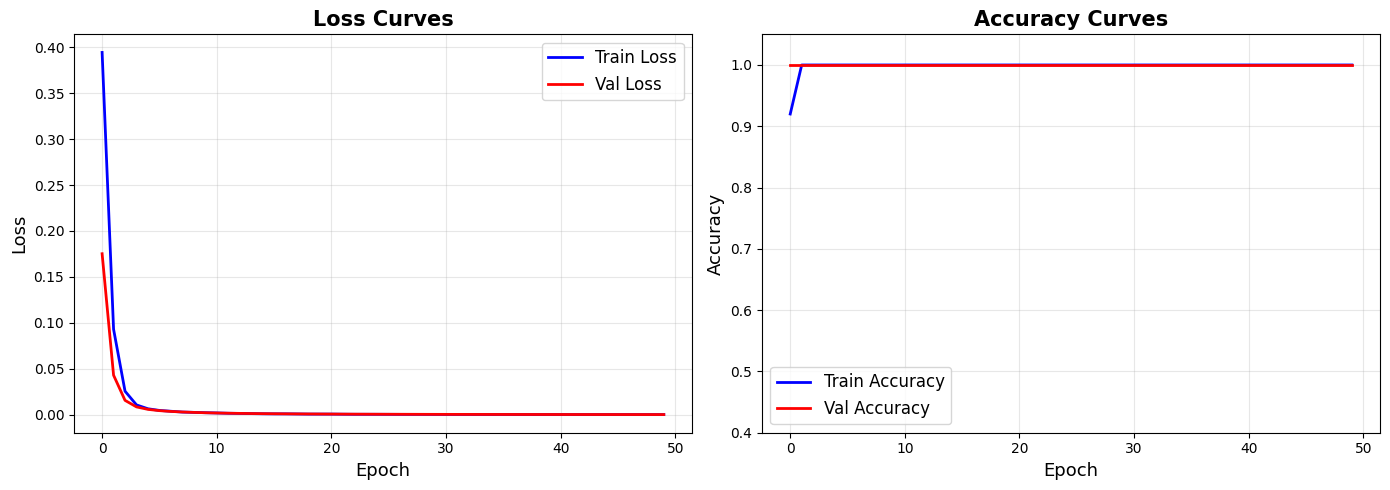


💡 결과 분석:
  - Train/Val Loss가 함께 감소 → 잘 학습되고 있음
  - Val Loss가 증가하기 시작하면 → 과적합 시작 (Early Stopping 필요)
  - LLM 파인튜닝에서도 동일한 원리가 적용됩니다!


In [16]:
# 학습 결과 시각화
print("📊 학습 결과 시각화")
print("=" * 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss 곡선
ax1.plot(train_losses, 'b-', linewidth=2, label='Train Loss')
ax1.plot(val_losses, 'r-', linewidth=2, label='Val Loss')
ax1.set_xlabel('Epoch', fontsize=13)
ax1.set_ylabel('Loss', fontsize=13)
ax1.set_title('Loss Curves', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Accuracy 곡선
ax2.plot(train_accs, 'b-', linewidth=2, label='Train Accuracy')
ax2.plot(val_accs, 'r-', linewidth=2, label='Val Accuracy')
ax2.set_xlabel('Epoch', fontsize=13)
ax2.set_ylabel('Accuracy', fontsize=13)
ax2.set_title('Accuracy Curves', fontsize=15, fontweight='bold')
ax2.legend(fontsize=12)
ax2.set_ylim(0.4, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 결과 분석:")
print("  - Train/Val Loss가 함께 감소 → 잘 학습되고 있음")
print("  - Val Loss가 증가하기 시작하면 → 과적합 시작 (Early Stopping 필요)")
print("  - LLM 파인튜닝에서도 동일한 원리가 적용됩니다!")

---
## 📝 9. 정리 및 핵심 요약

### 🎯 이번 세션에서 배운 핵심 개념

| # | 개념 | LLM 파인튜닝과의 관계 |
|---|------|---------------------|
| 1️⃣ | **활성화 함수** | GELU가 트랜스포머의 표준 |
| 2️⃣ | **Cross-Entropy Loss** | NTP 기반 LLM 학습의 핵심 손실 함수 |
| 3️⃣ | **역전파** | PyTorch autograd가 자동 처리 |
| 4️⃣ | **AdamW** | LLM 파인튜닝의 표준 옵티마이저 |
| 5️⃣ | **하이퍼파라미터** | lr, batch_size, epochs가 핵심 |
| 6️⃣ | **과적합 방지** | Dropout, Weight Decay, Early Stopping |

### 🔑 RTX 4060 (8GB) 파인튜닝 시 기억할 설정

```python
# 권장 하이퍼파라미터 (LoRA 파인튜닝 기준)
training_args = {
    "learning_rate": 2e-4,
    "per_device_train_batch_size": 1,
    "gradient_accumulation_steps": 8,
    "num_train_epochs": 3,
    "warmup_ratio": 0.03,
    "max_seq_length": 1024,
    "fp16": True,
    "optim": "adamw_torch",
    "weight_decay": 0.01,
}
```

### 📚 다음 세션 예고
- **Session 13**: 파인튜닝 개념 정리 - SFT/RL, CPT/IT, LoRA/QLoRA의 원리를 깊이 학습합니다.

In [17]:
# 메모리 정리
del model, optimizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print_gpu_memory("정리 후")

print("\n✅ Session 12 완료!")
print("📚 다음 세션: 파인튜닝 개념 정리 (SFT, LoRA, QLoRA)")

[정리 후] GPU: 0.0GB / 7.8GB

✅ Session 12 완료!
📚 다음 세션: 파인튜닝 개념 정리 (SFT, LoRA, QLoRA)
